### Customer Intelligence System: Segmentation and Predictive Analytics using Machine Learning

**Objective:**

To categorise the countries using socio-economic and health factors that determine the overall development of the country.

**About organization:**

HELP International is an international humanitarian NGO that is committed to fighting poverty and providing the people of backward countries with basic amenities and relief during the time of disasters and natural calamities.

**Problem Statement:**

HELP International have been able to raise around $ 10 million. Now the CEO of the NGO needs to decide how to use this money strategically and effectively. So, CEO has to make decision to choose the countries that are in the direst need of aid. Hence, your Job as a Data scientist is to categorise the countries using some socio-economic and health factors that determine the overall development of the country. Then you need to suggest the countries which the CEO needs to focus on the most.

**Dataset:**

| Feature | Description |
|:---|:---|
| country | Name of the country |
| child_mort | Death of children under 5 years of age per 1000 live births |
| exports | Exports of goods and services per capita, as % of GDP per capita |
| health | Total health spending per capita, as % of GDP per capita |
| imports | Imports of goods and services per capita, as % of GDP per capita |
| income | Net income per person |
| inflation | Annual growth rate of total GDP |
| life_expec | Average number of years a newborn child would live if current mortality patterns remain the same |
| total_fer | Number of children born to each woman if current age-fertility rates remain the same |
| gdpp | GDP per capita — total GDP divided by total population |


**High Level Approach:**

*   Import data, check dtypes, check shape
*   Summary statistics — distributions, missing values, outliers
*   Handle missing values and outliers (if applicable)
*   Examine skew and correlation - heatmap, pairplot
*   Apply transformations (log for skewed features, if applicable) and scale
*   Dimensionality reduction for visualisation (PCA to 2D)
*   Determine optimal K (elbow + silhouette)
*   Run clustering models (K-Means,DBSCAN)
*   Evaluate and compare — visual cluster plots, silhouette scores
*   Select best model and interpret clusters — profile each cluster's feature means
*   Map countries to clusters, identify the most at-risk group
*   Write recommendations to CEO of HELP International

In [1]:
# Import data manipulation and analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import visualization libraries for statistical plots and interactive charts
import seaborn as sns
import plotly.express as px

# Import machine learning preprocessing and clustering algorithms
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# EDA

In [2]:
df = pd.read_csv("./data/Country-data.csv")

In [3]:
# Check Data types
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [4]:
# Check for NaNs
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
# Check for dupes
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


**Initial Findings:**


*   There are no null values and no duplicates.
*   All features are numerical except `country`. `income` and `gdpp` are integer type; all features will be normalised using StandardScaler prior to modelling.
*   Negative inflation (deflation) is observed in the dataset. Deflation means goods and services become cheaper over time, but sustained deflation is not always positive as it can suppress economic growth and signal weak demand [1].



In [7]:
# Drop country column to plot feature distributions/visualizations
col_names = df.columns.drop("country")
col_names

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

### Most features reflect the extreme divides between wealthy and underdeveloped nations

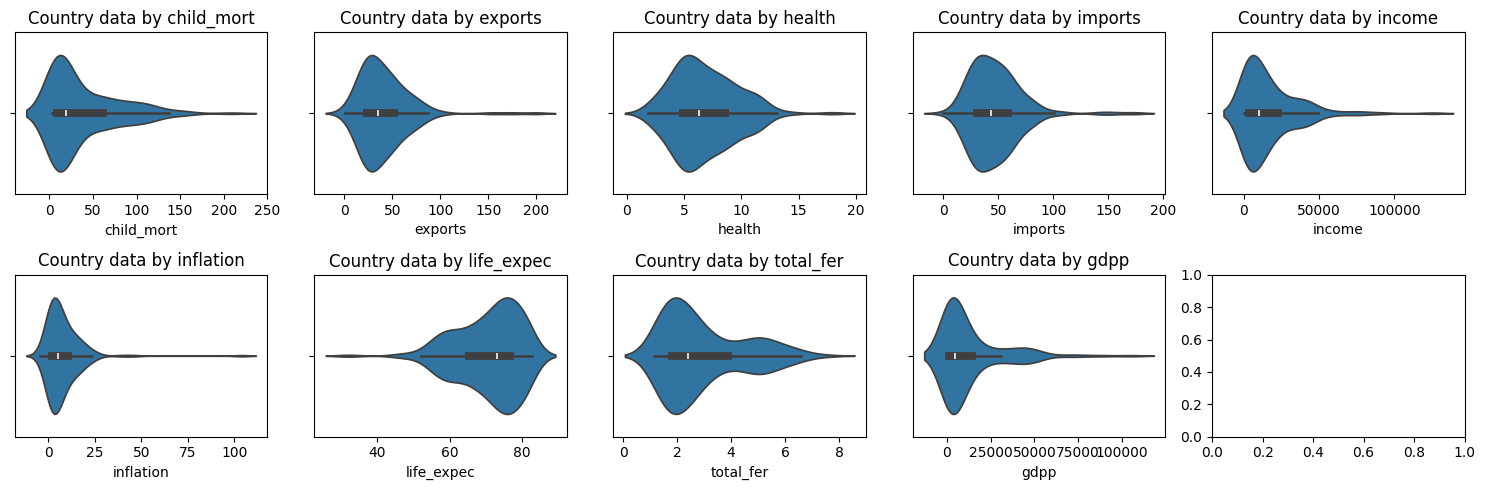

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5)) # Setup a 2x5 grid (2 rows, 5 columns)

axes = axes.flatten() # This lets us use axes[c] instead of axes[row, col]
# Loop through each column and create a violin plot
for c, col_name in enumerate(col_names):
    sns.violinplot(data=df, x=col_name,
                 ax=axes[c], gap = 0.1)

    axes[c].set_title(f"Country data by {col_name}")
plt.tight_layout()
plt.show()

## Insights - violinplots

- Most features are **heavily skewed**, which is expected given the dataset spans both highly wealthy and severely underdeveloped countries.
- Globally, most women are having **two children**, however there is a secondary concentration around **five children**, suggesting a clear split between developed and developing nations.
- **Health spending** shows the most Gaussian-like distribution of all features, suggesting that health expenditure as a % of GDP is relatively evenly spread across countries, with an IQR of 3.68% (noted in summary statistics above).
- Imports and exports show similar distribution shapes with a slightly higher mean for imports. While this has broader economic implications, these features are weaker indicators of a country's need for aid and will not be a primary focus of this analysis.


### High health expenditure does not always guarantee good outcomes; governance and accountability matter just as much as the money itself.

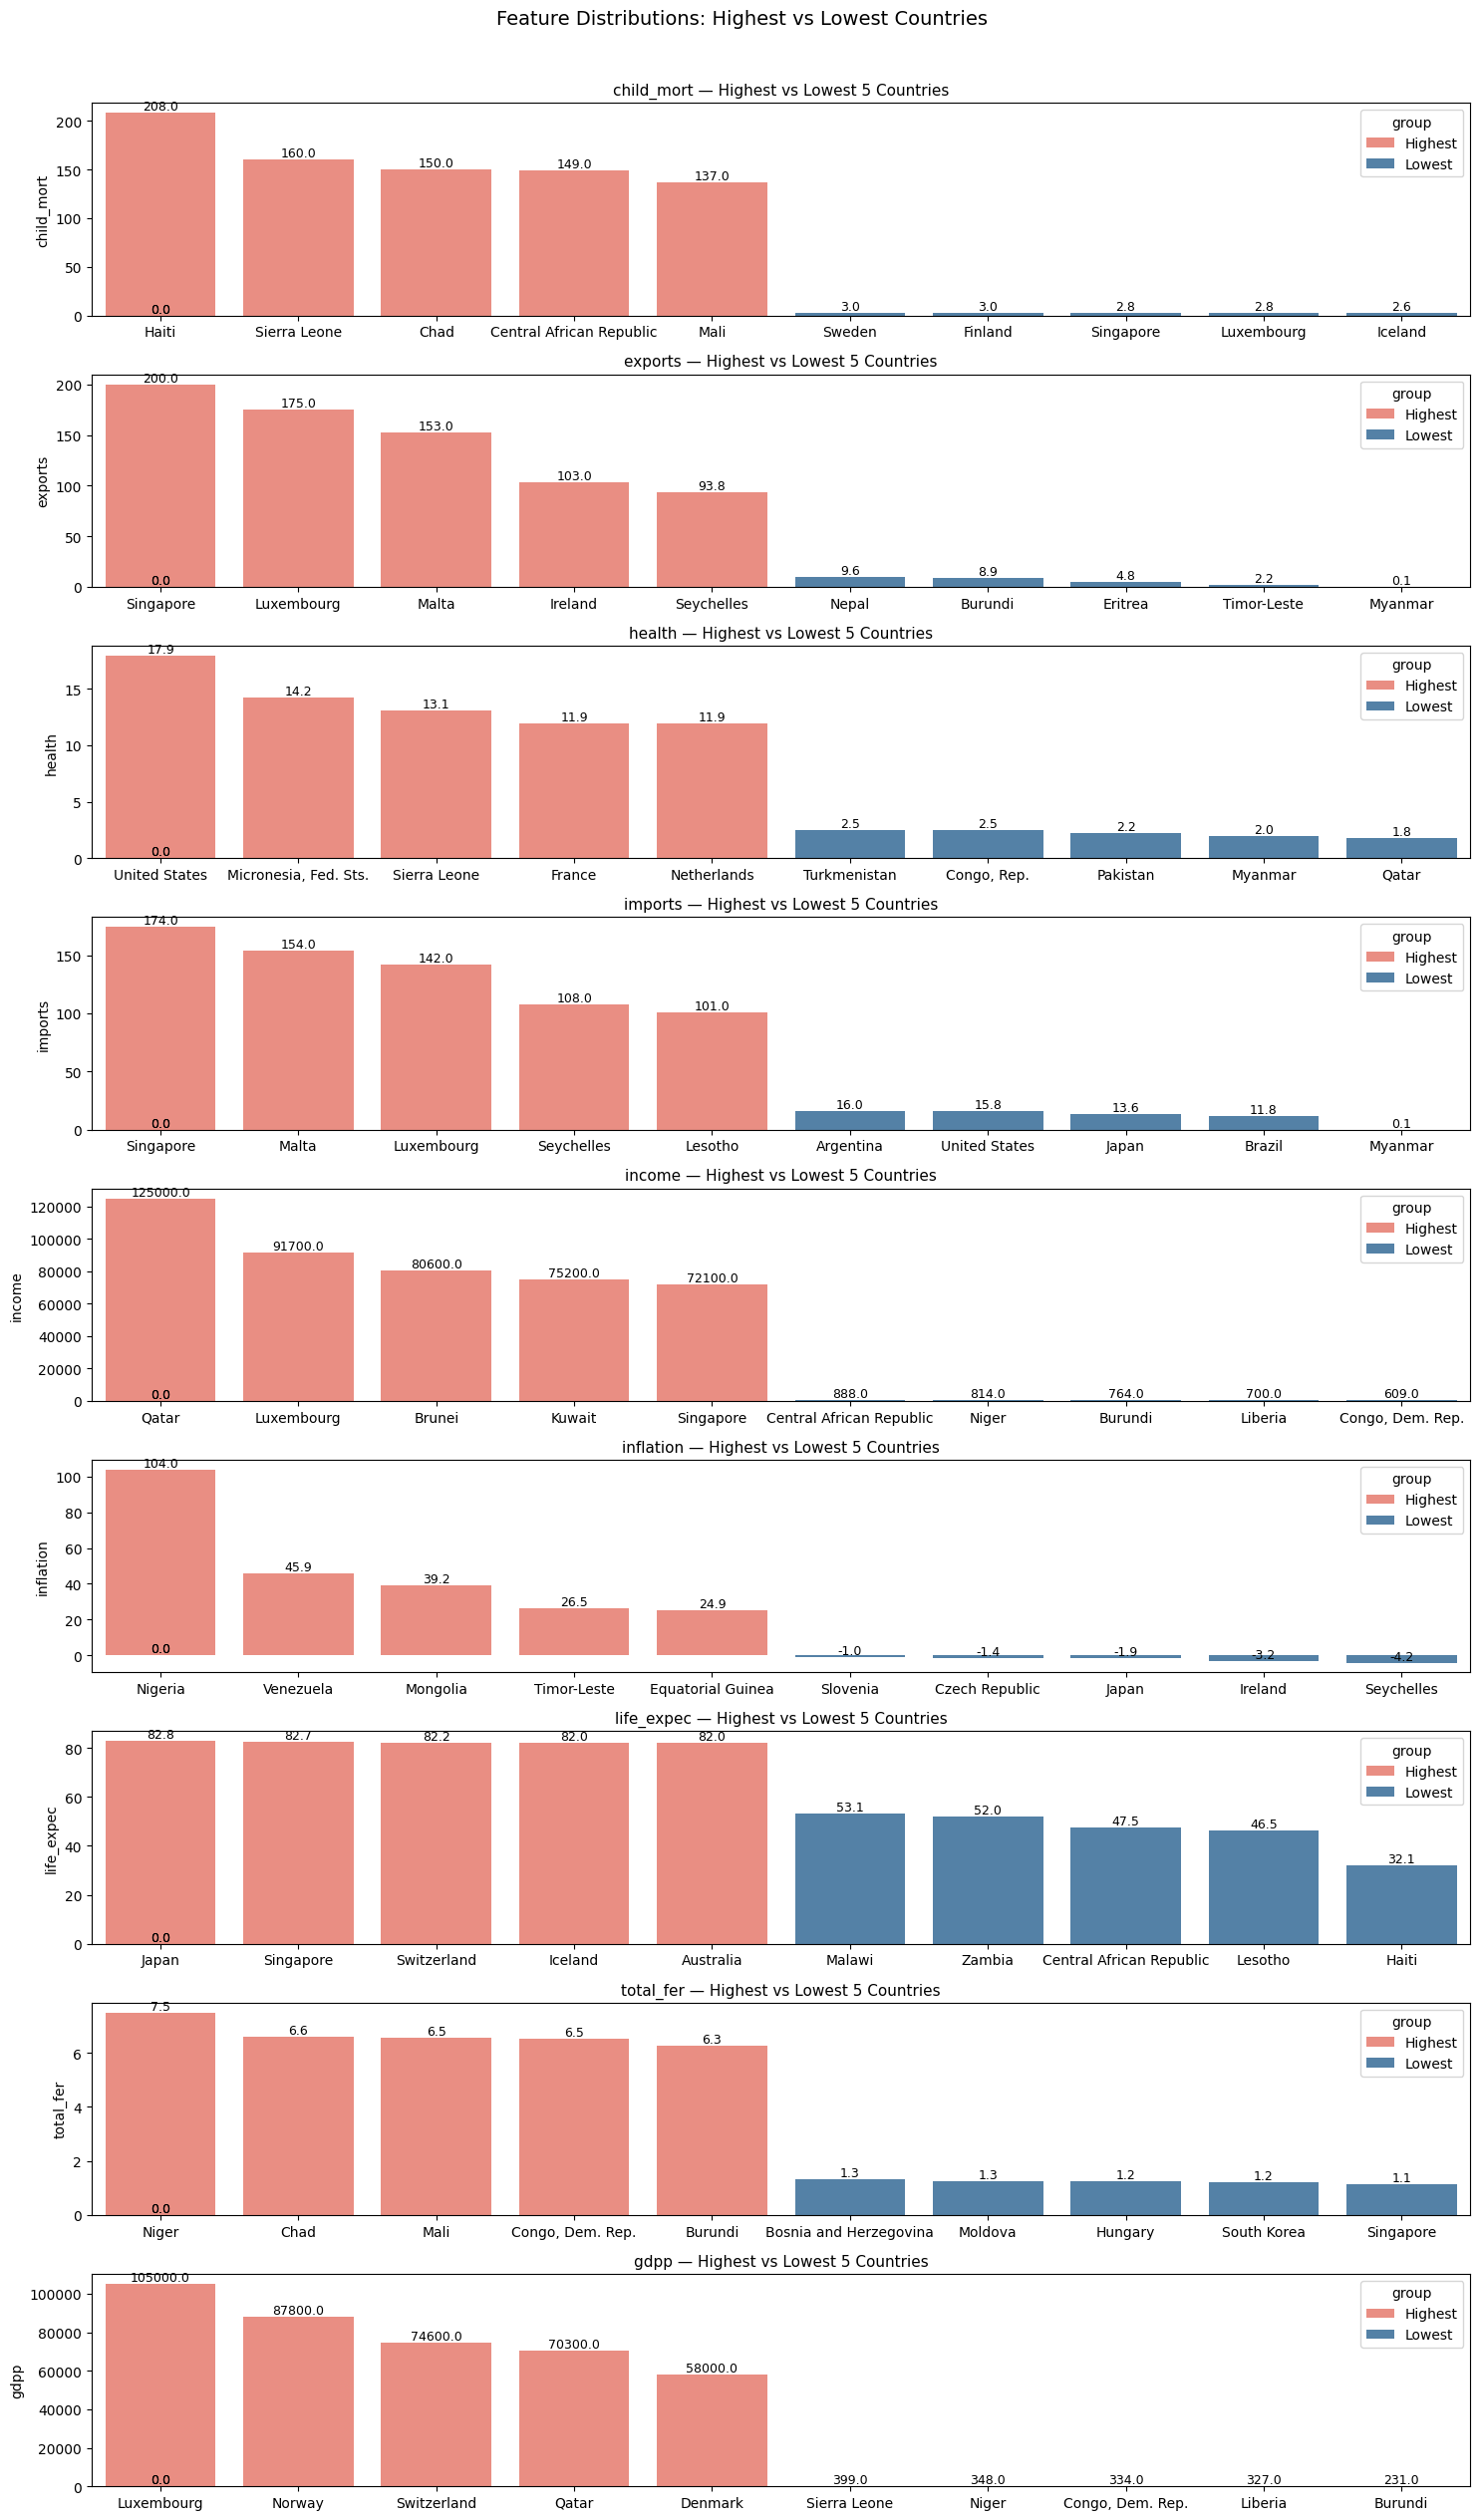

In [9]:
# Top 5 / Bottom 5 view code adapted from [2]
fig, axes = plt.subplots(9,1, figsize=(15, 25))

for i, feature in enumerate(col_names):
    top5 = df.sort_values(by=feature, ascending=False).iloc[:5].copy()
    bottom5 = df.sort_values(by=feature, ascending=True).iloc[:5].copy()

    top5['group'] = 'Highest'
    bottom5['group'] = 'Lowest'

    combined = pd.concat([top5, bottom5]).sort_values(by=feature, ascending=False)

    bars = sns.barplot(x='country', y=feature, data=combined,
                       hue='group', palette={'Highest': 'salmon', 'Lowest': 'steelblue'},
                       dodge=False, ax=axes[i])

    # add numbers on bars
    for bar in bars.patches:
        height = bar.get_height()
        bars.annotate(f'{height:.1f}',
                      (bar.get_x() + bar.get_width() / 2, height),
                      ha='center', va='bottom', fontsize=9)

    axes[i].set_title(f'{feature} — Highest vs Lowest 5 Countries', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

plt.suptitle('Feature Distributions: Highest vs Lowest Countries', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Insights - barplots

- Most countries with the worst socio-economic indicators are concentrated in Africa.
- Haiti has the highest child mortality rate - roughly 2 in every 10 children under five are currently dying.
- Nigeria and Venezuela have the highest inflation rates, with Nigeria's hyperinflation likely reflecting a deeper political and monetary crisis rather than purely economic mismanagement.
- Niger has the highest fertility rate at 7.5 children per woman; Singapore the lowest at 1.1. Persistently low fertility carries long-term consequences, including aging populations and shrinking workforces.
- Luxembourg, Switzerland, Singapore, Qatar, and Japan consistently rank well across positive indicators (exports, imports, GDP, and income).
- Health spending is one of the more interesting findings. Despite Sierra Leone ranking third globally for health expenditure as a % of GDP, it remains second highest in child mortality. This raises serious questions about how funds are being allocated and managed, and suggests that aid alone is insufficient. Any intervention should also address policy, governance, and funding accountability to ensure lasting impact.
- Overall, the countries most in need of aid are heavily concentrated in Africa.









## Choropleth map

The choropleth maps below bring the socio-economic indicators to life geographically. Concentrations of negative indicators are visible primarily across Africa, with pockets also appearing in parts of Asia and South America.

* I came across choropleth mapping in Python for the first time through this Kaggle notebook.

In [11]:
for i in df.drop('country', axis=1).columns:
    fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',
                         title=i+' Per Country',color=i,color_continuous_scale="Teal")
    fig.update_geos(fitbounds="locations", visible=True)
    fig.show(engine='kaleido')


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_2696\1383278977.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df, locationmode='country names', locations='country',projection='albers',


# outlier detection

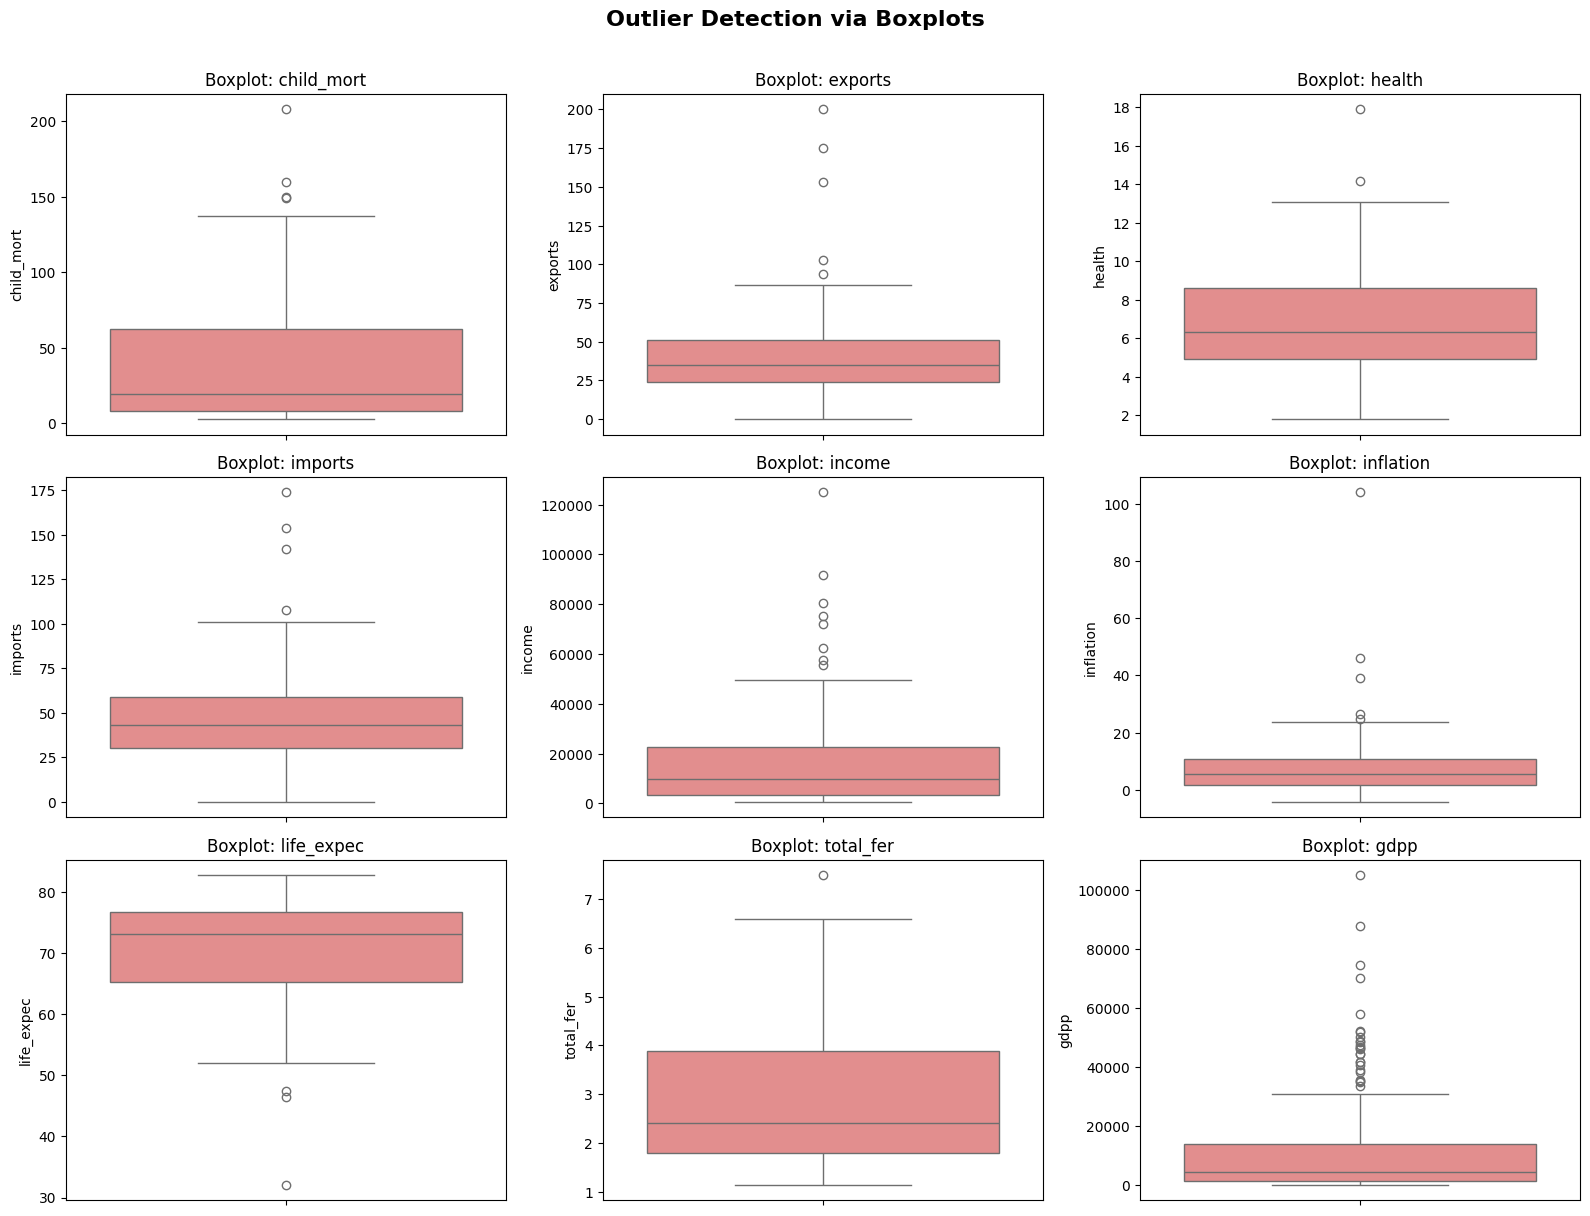

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(col_names):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Outlier Detection via Boxplots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Skewness

In [13]:
df_model = df.drop(["country"],axis=1)
df_model.skew().sort_values()

life_expec   -0.970996
health        0.705746
total_fer     0.967092
child_mort    1.450774
imports       1.905276
gdpp          2.218051
income        2.231480
exports       2.445824
inflation     5.154049
dtype: float64

`country` is dropped from the model at this stage — it serves as an identifier only and carries no socio-economic signal. It will be reattached later to interpret which countries fall into each cluster.

Skewness is assessed using the following thresholds:

| Range | Interpretation |
|:---|:---|
| Between -0.5 and 0.5 | Roughly symmetric, no action needed |
| Between 0.5 and 1 (or -0.5 to -1) | Moderate skew, worth noting |
| Above 1 or below -1 | Significant skew, consider log transformation |

Inflation has the largest skew across all features.

However, log transformation will not be applied here. The skew in this dataset is meaningful as it reflects the real-world extremes between the wealthiest and most underdeveloped countries. Removing it would smooth away the very signal we are trying to capture.

It is also worth noting that skew is arguably more consequential in supervised learning, where it can imbalance a model and introduce bias toward the majority class. In unsupervised clustering, preserving the natural distribution is often preferable, particularly when the goal is to identify outliers, as it is here.

## Correlation

<Axes: >

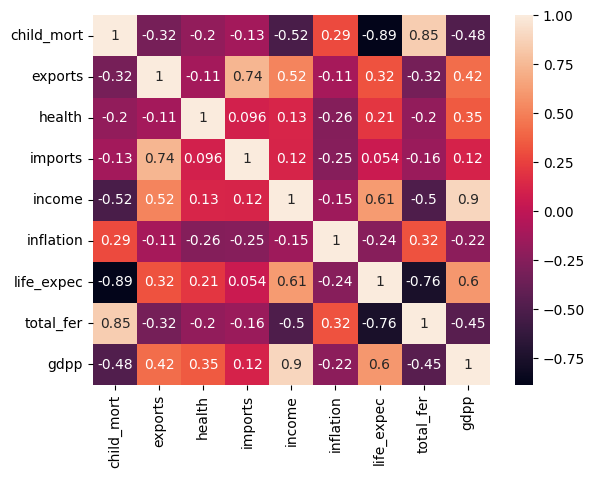

In [14]:
sns.heatmap(df_model.corr(),annot=True)

The heatmap reveals three notably high correlations (|r| > 0.85):

| Feature Pair | Correlation |
|:---|:---|
| GDP & Income | 0.90 |
| Life expectancy & Child mortality | -0.89 |
| Total fertility & Child mortality | 0.85 |

`income` will be dropped from the model as GDP and income are the most highly correlated pair, and `gdpp` is the more informative feature to retain for a development analysis.

For the remaining correlated pairs, a few options were considered: dropping `child_mort` (correlated with two features) or applying PCA to handle the redundancy automatically. Ultimately, all remaining features will be retained because keeping the original features makes it straightforward to interpret what is driving each cluster and communicate findings clearly.

## Feature Scaling

In [15]:
# Drop Income
df_model = df_model.drop(["income"],axis=1)
df_model.head()

,child_mort,exports,health,imports,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,1.44,76.8,2.13,12200


# Scaling

In [16]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model),
    columns=df_model.columns
)
df_scaled.head()

,child_mort,exports,health,imports,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,-0.601749,0.704258,-0.541946,-0.041817


# Modelling

## K-Means Clustering

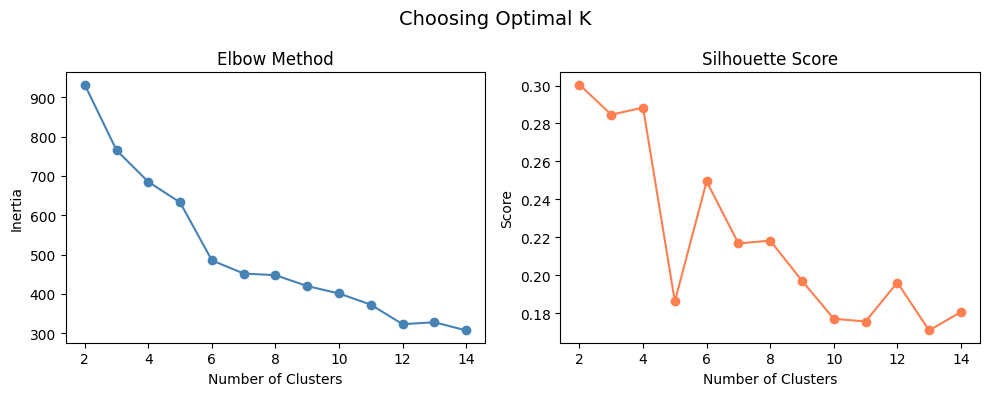

In [17]:
# Determine optimal K using the elbow method

inertia = []
silhouette_scores = []
list_num_clusters = list(range(2, 15))  # start from 2 for silhouette

for num_clusters in list_num_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# elbow plot
ax1.plot(list_num_clusters, inertia, marker='o', color='steelblue')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')

# silhouette plot
ax2.plot(list_num_clusters, silhouette_scores, marker='o', color='coral')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Score')

plt.suptitle('Choosing Optimal K', fontsize=14)
plt.tight_layout()
plt.show()

### Choosing Optimal K

Inertia measures how internally compact clusters are, which is calculated as the sum of squared distances between each data point and its nearest centroid. Lower inertia indicates tighter clusters.

Selecting the optimal K is not straightforward here. There is no obvious elbow in the inertia plot, with the curve beginning to plateau somewhere between 6 and 8 clusters. However, thinking contextually, countries are broadly categorised into three development tiers: underdeveloped, developing, and developed, which naturally suggests K=3.

The silhouette score at K=3 is ~0.28, which, while relatively high compared to other values on the plot, is still weak in absolute terms (closer to 1 is ideal). This suggests a weaker inter-cluster separation (expected for this type of data) where development is a spectrum rather than a set of discrete categories, and where many complex factors interact to determine a country's socio-economic status. K=3 is retained primarily for explainability and interpretability when presenting findings.

### A Note on PCA

PCA is used here for visualisation only - not dimensionality reduction. With `income` already dropped, the dataset sits at 9 features, which is low enough to cluster on directly. However, 9 dimensions cannot be visualised directly. PCA condenses the 9 features into two principal components (PC1 and PC2), each a weighted combination of all features, giving a 2D plot that represents the full 9-dimensional structure as best as possible. This is preferable to simply plotting two raw features, which would only capture a fraction of the information driving the clusters. The clusters are built in 9-dimensional space. PCA is simply the window we look through to see them.

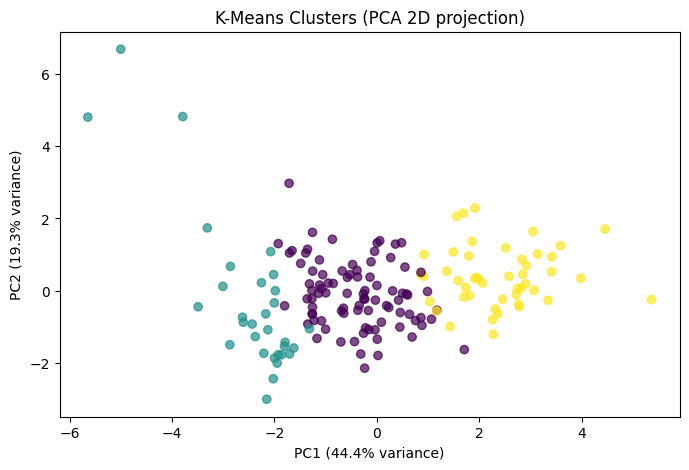

In [25]:
# PCA for visualisation only. We will use PC1 and PC2 to plot all model vizualizations
pca_viz = PCA(n_components=2,random_state=42)
df_2d = pca_viz.fit_transform(df_scaled)
# fit k-means and get labels
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels = kmeans.fit_predict(df_scaled)
df['KMeans_Clusters'] = labels
# plot
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df_2d[:, 0], df_2d[:, 1], c=labels, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (PCA 2D projection)')
plt.show()

## DBSCAN

Density-Based Spatial Clustering of Applications with Noise (DBSCAN) identifies clusters based on the density of neighbouring points, rather than simply partitioning the data as K-Means does. It expands clusters outward from high-density core points, and any point that cannot be assigned to a dense region is labelled as noise, meaning DBSCAN is one of the few algorithms that can explicitly say "this point does not belong to any cluster."

This makes it particularly well-suited to datasets with significant noise or irregularly shaped clusters. The algorithm terminates once every point has been classified as either a cluster member or noise.

In [20]:
# test a range of eps values to find the most suitable neighbourhood radius
for eps in [0.3, 0.5, 0.8, 1.0, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)  # min_samples=5 is a standard starting point
    labels_db = db.fit_predict(df_scaled)

    # DBSCAN labels noise points as -1, so subtract 1 from cluster count if noise exists
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

    # count points labelled as noise (-1)
    n_noise = (labels_db == -1).sum()

    print(f'eps={eps} → clusters: {n_clusters}, noise points: {n_noise}')

eps=0.3 → clusters: 0, noise points: 167
eps=0.5 → clusters: 0, noise points: 167
eps=0.8 → clusters: 5, noise points: 133
eps=1.0 → clusters: 3, noise points: 91
eps=1.5 → clusters: 1, noise points: 27


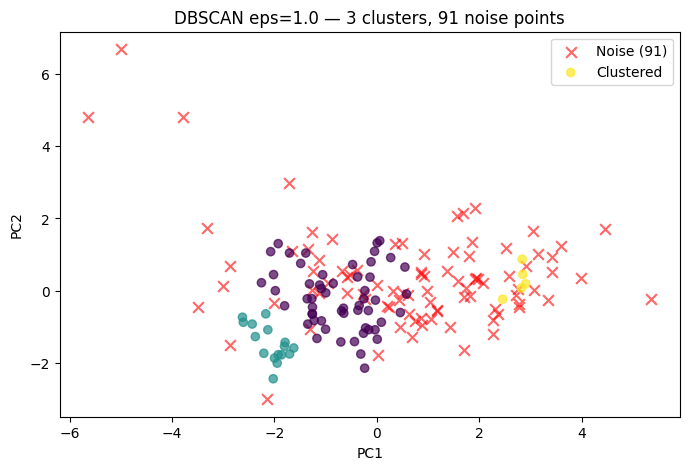

In [21]:
# fit DBSCAN with best eps value identified from tuning above
db = DBSCAN(eps=1.0, min_samples=5)
# Epsilon (eps) ε: radius of local neighbourhood – how far away does a point need to be to be considered as part of that cluster
# N_clu (min samples): determined density threshold (for fixed ε) – minimum number of points to be considered a core point for a cluster
# Core points are those which have more than n_clue neighbours in their local neighbourhood (“ε-neighbourhood”)
# All clusters require at least one core point.
labels_db = db.fit_predict(df_scaled)

# count clusters (excluding noise) and noise points
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

fig, ax = plt.subplots(figsize=(8, 5))

# plot noise points first so cluster points render on top
noise_mask = labels_db == -1
ax.scatter(df_2d[noise_mask, 0], df_2d[noise_mask, 1],
           c='red', marker='x', s=60, alpha=0.6, label=f'Noise ({n_noise})')

# plot clustered points, coloured by cluster assignment
cluster_mask = labels_db != -1
scatter = ax.scatter(df_2d[cluster_mask, 0], df_2d[cluster_mask, 1],
                     c=labels_db[cluster_mask], cmap='viridis', alpha=0.7,
                     label='Clustered')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN eps=1.0 — {n_clusters} clusters, {n_noise} noise points')
ax.legend()
plt.show()

# Evaluation

The below section focuses on mapping the countries back to the dataset used for modelling, to analyse which countries were assigned to each cluster by the model. We can also label the clusters with more meaningful class names reflecting the socio economic status of each cluster of countries (developed, developing, and underdeveloped).

In [22]:
# Select K-Means model as the final model
df_results_km = df.copy()
df_results_km['cluster'] = labels
# Sort by GDP to identify developed/developing/underdeveloped classes
df_results_km.groupby('cluster')[df_model.columns].mean().round(2).sort_values(by='gdpp')

,child_mort,exports,health,imports,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,
2,92.96,29.15,6.39,42.32,12.02,59.19,5.01,1922.38
0,21.17,41.70,6.09,47.27,7.75,73.08,2.28,7825.42
1,4.43,57.55,9.55,52.73,1.46,80.54,1.74,44458.06


## Sunburst Analysis

This section deep-dives into the three clusters identified by K-Means, examining the countries assigned to each through an interactive visual lens. It serves three purposes:

1.   to verify that cluster assignments are contextually sensible: do the right countries end up in the right groups?
2.   to provide a compelling visual for the CEO of HELP International that brings the scale of global inequality to life and clearly identifies where aid is needed most
3. to explore the complex relationships between socio-economic features, such as the interplay between GDP and child mortality rates.

In [23]:
# code adapted from [3]
fig = px.sunburst(
    df_results_km,
    path=["cluster", "country"],
    values="gdpp",
    color="inflation",
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=7,
    range_color=[0, 20],  # mean inflation is 7.78 - this clamps inflation >20 the darkest shade
    width=1000,
    height=700
)

fig.update_layout(
    title="GDP of each country by Inflation",
    title_font={"size": 20},
    margin=dict(t=50, b=50, l=0, r=0),
)

fig.show()


In [26]:
from sklearn.model_selection import train_test_split

x= df_scaled.copy()

y= df['KMeans_Clusters']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(133, 8)
(34, 8)


In [27]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
}
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='f1_macro'
    )

    print(f'\n{name}')
    print('CV Scores:', scores)
    print('Mean F1 Macro:', round(scores.mean(),3))


Random Forest
CV Scores: [0.95820272 0.89444444 0.93015873 1.         0.9654321 ]
Mean F1 Macro: 0.95

AdaBoost
CV Scores: [0.95820272 0.89444444 0.93015873 0.9654321  1.        ]
Mean F1 Macro: 0.95

XGBoost
CV Scores: [0.95820272 0.95146871 0.92366522 0.95735129 1.        ]
Mean F1 Macro: 0.958


In [28]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train,y_train)

print("Best RF Params:",rf_grid.best_params_)
print("Best RF CV Score:",rf_grid.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best RF CV Score: 0.9522826834654792


In [29]:
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_grid=xgb_params,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Params:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV Score: 0.966661248500329


## Hyperparameter Tuning Results

The two best-performing models from cross-validation, **Random Forest** and **XGBoost**, were further optimized using Grid Search with Stratified 5-Fold Cross-Validation.

- The tuned **Random Forest** model achieved a Mean F1-Macro score of **0.9522**.
- The tuned **XGBoost** model achieved a Mean F1-Macro score of **0.966**.

### Observation

- Both models demonstrated strong predictive performance after tuning.
- XGBoost achieved the highest cross-validation score and outperformed Random Forest.
- Based on these results, **XGBoost was selected as the final classification model** for predicting cluster membership.

In [30]:
best_xgb = xgb_grid.best_estimator_
y_pred = best_xgb.predict(X_test)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:",round(accuracy_score(y_test,y_pred),3))
print("Precision:",round(precision_score(y_test,y_pred,average='macro'),3))
print("Recall:",round(recall_score(y_test,y_pred,average='macro'),3))
print("F1:",round(f1_score(y_test,y_pred,average='macro'),3))
print(classification_report(y_test,y_pred))

Accuracy: 0.912
Precision: 0.952
Recall: 0.878
F1: 0.907
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        18
           1       1.00      0.83      0.91         6
           2       1.00      0.80      0.89        10

    accuracy                           0.91        34
   macro avg       0.95      0.88      0.91        34
weighted avg       0.92      0.91      0.91        34



# Recommendations

### List of countries in alphabetical order by socio economic category

| # | 🔴 Underdeveloped (47) | 🟡 Developing (89) | 🟢 Developed (31) |
|:---|:---|:---|:---|
| 1 | Afghanistan | Albania | Australia |
| 2 | Angola | Algeria | Austria |
| 3 | Benin | Antigua and Barbuda | Belgium |
| 4 | Botswana | Argentina | Canada |
| 5 | Burkina Faso | Armenia | Cyprus |
| 6 | Burundi | Azerbaijan | Czech Republic |
| 7 | Cameroon | Bahamas | Denmark |
| 8 | Central African Republic | Bahrain | Finland |
| 9 | Chad | Bangladesh | France |
| 10 | Comoros | Barbados | Germany |
| 11 | Congo, Dem. Rep. | Belarus | Greece |
| 12 | Congo, Rep. | Belize | Iceland |
| 13 | Cote d'Ivoire | Bhutan | Ireland |
| 14 | Equatorial Guinea | Bolivia | Israel |
| 15 | Eritrea | Bosnia and Herzegovina | Italy |
| 16 | Gabon | Brazil | Japan |
| 17 | Gambia | Brunei | Luxembourg |
| 18 | Ghana | Bulgaria | Malta |
| 19 | Guinea | Cambodia | Netherlands |
| 20 | Guinea-Bissau | Cape Verde | New Zealand |
| 21 | Haiti | Chile | Norway |
| 22 | Iraq | China | Portugal |
| 23 | Kenya | Colombia | Qatar |
| 24 | Kiribati | Costa Rica | Singapore |
| 25 | Lao | Croatia | Slovak Republic |
| 26 | Lesotho | Dominican Republic | Slovenia |
| 27 | Liberia | Ecuador | Spain |
| 28 | Madagascar | Egypt | Sweden |
| 29 | Malawi | El Salvador | Switzerland |
| 30 | Mali | Estonia | United Kingdom |
| 31 | Mauritania | Fiji | United States |
| 32 | Mozambique | Georgia | |
| 33 | Namibia | Grenada | |
| 34 | Niger | Guatemala | |
| 35 | Nigeria | Guyana | |
| 36 | Pakistan | Hungary | |
| 37 | Rwanda | India | |
| 38 | Senegal | Indonesia | |
| 39 | Sierra Leone | Iran | |
| 40 | South Africa | Jamaica | |
| 41 | Sudan | Jordan | |
| 42 | Tanzania | Kazakhstan | |
| 43 | Timor-Leste | Kuwait | |
| 44 | Togo | Kyrgyz Republic | |
| 45 | Uganda | Latvia | |
| 46 | Yemen | Lebanon | |
| 47 | Zambia | Libya | |
| 48 | | Lithuania | |
| 49 | | Macedonia, FYR | |
| 50 | | Malaysia | |
| 51 | | Maldives | |
| 52 | | Mauritius | |
| 53 | | Micronesia, Fed. Sts. | |
| 54 | | Moldova | |
| 55 | | Mongolia | |
| 56 | | Montenegro | |
| 57 | | Morocco | |
| 58 | | Myanmar | |
| 59 | | Nepal | |
| 60 | | Oman | |
| 61 | | Panama | |
| 62 | | Paraguay | |
| 63 | | Peru | |
| 64 | | Philippines | |
| 65 | | Poland | |
| 66 | | Romania | |
| 67 | | Russia | |
| 68 | | Samoa | |
| 69 | | Saudi Arabia | |
| 70 | | Serbia | |
| 71 | | Seychelles | |
| 72 | | Solomon Islands | |
| 73 | | South Korea | |
| 74 | | Sri Lanka | |
| 75 | | St. Vincent and the Grenadines | |
| 76 | | Suriname | |
| 77 | | Tajikistan | |
| 78 | | Thailand | |
| 79 | | Tonga | |
| 80 | | Tunisia | |
| 81 | | Turkey | |
| 82 | | Turkmenistan | |
| 83 | | Ukraine | |
| 84 | | United Arab Emirates | |
| 85 | | Uruguay | |
| 86 | | Uzbekistan | |
| 87 | | Vanuatu | |
| 88 | | Venezuela | |
| 89 | | Vietnam | |

# Section 14

- 47 out of 167 countries (28%) were identified as being in need of aid, representing predominantly underdeveloped nations across Africa.

- In terms of immediate and urgent intervention, the country I would prioritise first is **Haiti**. It has the highest child mortality rate in the dataset, with approximately 2 in every 10 children dying before the age of five, indicating a severe humanitarian crisis and significant risk to vulnerable populations. Haiti also has the lowest life expectancy, likely driven in part by this extremely high mortality rate.

- I would also recommend prioritising countries with the lowest life expectancy first: **Lesotho, Central African Republic, Zambia, and Malawi**, in that order. This should be followed by countries with the highest child mortality rates after Haiti: **Sierra Leone, Chad, and Mali**.

- Beyond these highest-priority cases, the remaining underdeveloped countries should be considered with broadly equal importance. However, several operational factors should also influence final decision-making, including accessibility to vulnerable communities, the presence of established charities or NGOs in the region, geographical proximity to neighbouring aid locations for easier transportation of supplies, political stability, and overall safety. Existing international relationships and supply routes may also help accelerate the delivery of essentials such as food and medicine, providing quicker short-term impact. Countries requiring significant physical infrastructure or on-the-ground coordination may require longer-term logistical planning. Careful collaboration with regional experts and humanitarian organisations will therefore be essential to ensure aid is distributed as efficiently and effectively as possible.

- The type of aid provided should also be tailored to each country’s circumstances. Some countries, as identified earlier, may face governance or corruption challenges that limit how effectively funding reaches those most in need. For example, despite Sierra Leone ranking highly for health expenditure as a percentage of GDP, it still experiences one of the highest child mortality rates globally. Countries such as these may benefit not only from financial aid, but also from stronger policy support, oversight, and governance-focused interventions to ensure resources are funnelled through the appropriate channels.

- I would also recommend approaching some of the world’s wealthiest countries to support the financing of these humanitarian efforts, particularly nations with high GDP and strong economic resources such as Luxembourg, Norway, Switzerland, Qatar (and European countries in general), as well as the United States and Australia. Additional fundraising strategies could also be explored, including targeted campaigns aimed at high-net-worth individuals and private donors.

- Finally, the majority of countries identified by the model fall within the “developing” category rather than the “underdeveloped” category. For this reason, the model should be re-run regularly using updated live data to ensure countries moving between development categories are accurately identified and prioritised over time.